In [ ]:
!pip install pandas numpy scikit-learn tensorflow matplotlib joblib


In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("city_hour.csv")

df['Datetime'] = pd.to_datetime(df['Datetime'])

# Use Hyderabad only
df = df[df['City'] == "Hyderabad"]

df = df.sort_values('Datetime')

# Time features
df['hour'] = df['Datetime'].dt.hour
df['dayofweek'] = df['Datetime'].dt.dayofweek
df['month'] = df['Datetime'].dt.month

# Cyclical encoding
df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)

df['day_sin'] = np.sin(2*np.pi*df['dayofweek']/7)
df['day_cos'] = np.cos(2*np.pi*df['dayofweek']/7)

df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)

features = [
'PM2.5','PM10','NO2','SO2','CO','O3',
'hour_sin','hour_cos',
'day_sin','day_cos',
'month_sin','month_cos'
]

df = df[['Datetime'] + features]

df = df.fillna(method='ffill')
df = df.dropna()

scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(df[features])

def create_dataset(data, past=72):

    X = []
    y = []

    for i in range(len(data)-past-1):
        X.append(data[i:(i+past)])
        y.append(data[i+past][:6])

    return np.array(X), np.array(y)

X, y = create_dataset(data_scaled)

split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Train shape:",X_train.shape)
print("Test shape:",X_test.shape)

Train shape: (33798, 72, 12)
Test shape: (8450, 72, 12)


/tmp/ipykernel_869/1403907364.py:38: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [2]:
!pip install tensorflow

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Conv1D,Bidirectional,LSTM
from tensorflow.keras.layers import Dense,Dropout,Attention,GlobalAveragePooling1D

inputs = Input(shape=(72,12))

x = Conv1D(128,3,activation='relu',padding='same')(inputs)
x = Dropout(0.05)(x)

x = Conv1D(64,3,activation='relu',padding='same')(x)

x = Bidirectional(LSTM(128,return_sequences=True))(x)
x = Dropout(0.1)(x)

x = Bidirectional(LSTM(64,return_sequences=True))(x)

attention = Attention()([x,x])

x = GlobalAveragePooling1D()(attention)

x = Dense(128,activation='relu')(x)
x = Dropout(0.05)(x)

x = Dense(64,activation='relu')(x)

outputs = Dense(6)(x)

model = Model(inputs,outputs)

model.compile(
optimizer=tf.keras.optimizers.Adam(0.001),
loss=tf.keras.losses.Huber(),
metrics=['mae']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 72, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 72, 128)   │      4,736 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 72, 128)   │          0 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 72, 64)    │     24,640 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 72, 256)   │    197,632 │ conv1d_5[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 72, 256)   │          0 │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 72, 128)   │    164,352 │ dropout_7[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_2         │ (None, 72, 128)   │          0 │ bidirectional_5[… │
│ (Attention)         │                   │            │ bidirectional_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention_2[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      8,256 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 6)         │        390 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 416,518 (1.59 MB)

 Trainable params: 416,518 (1.59 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

early_stop = EarlyStopping(
monitor='val_loss',
patience=12,
restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
monitor='val_loss',
factor=0.5,
patience=5,
min_lr=1e-6
)

history = model.fit(
X_train,
y_train,
epochs=120,
batch_size=32,
validation_data=(X_test,y_test),
callbacks=[early_stop,lr_scheduler]
)

Epoch 1/120
1057/1057 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - loss: 0.0024 - mae: 0.0413 - val_loss: 3.7111e-04 - val_mae: 0.0192 - learning_rate: 0.0010
Epoch 2/120
1057/1057 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - loss: 0.0012 - mae: 0.0270 - val_loss: 1.9692e-04 - val_mae: 0.0137 - learning_rate: 0.0010
Epoch 3/120
1057/1057 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - loss: 0.0010 - mae: 0.0243 - val_loss: 1.9551e-04 - val_mae: 0.0140 - learning_rate: 0.0010
Epoch 4/120
1057/1057 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - loss: 9.4365e-04 - mae: 0.0231 - val_loss: 1.8081e-04 - val_mae: 0.0133 - learning_rate: 0.0010
Epoch 5/120
1057/1057 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - loss: 8.3682e-04 - mae: 0.0220 - val_loss: 1.9100e-04 - val_mae: 0.0135 - learning_rate: 0.0010
Epoch 6/120
1057/1057 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - loss: 7.8587e-04 - mae: 0.0211 - val_loss: 1.6683e-04 - val_mae: 0.0128 - learning_rate: 0.0010
Epoch 7/120
1057/1057 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - loss: 7.2057e-04 - mae:

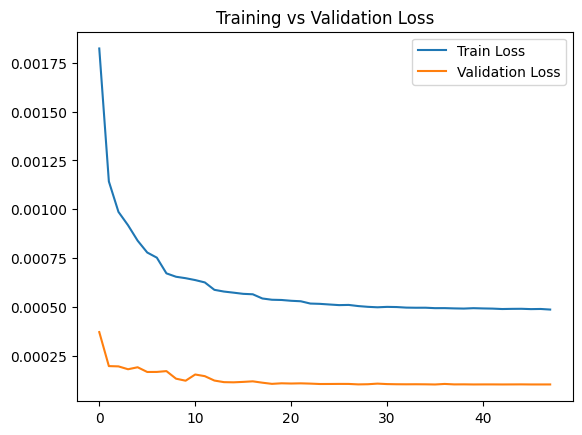

265/265 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
MAE: 3.3553133716690873
RMSE: 5.549152870545525


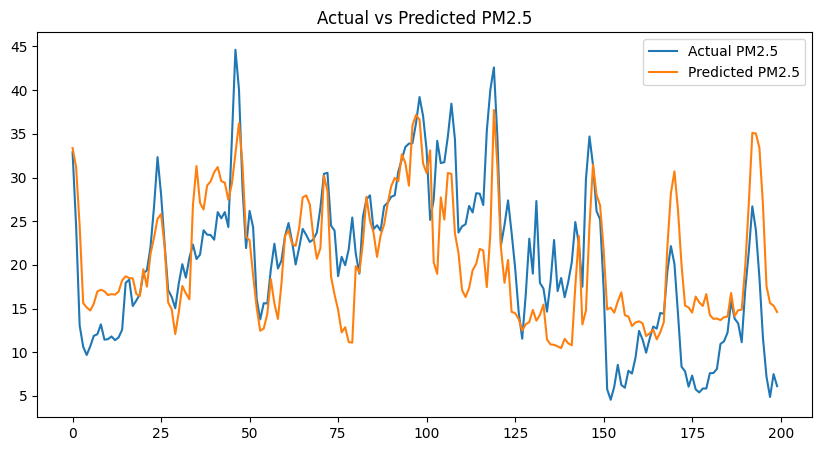

In [18]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

pred = model.predict(X_test)

pred_full = np.zeros((len(pred),12))
actual_full = np.zeros((len(y_test),12))

pred_full[:,:6] = pred
actual_full[:,:6] = y_test

pred = scaler.inverse_transform(pred_full)[:,:6]
actual = scaler.inverse_transform(actual_full)[:,:6]

mae = mean_absolute_error(actual,pred)
rmse = np.sqrt(mean_squared_error(actual,pred))


print("MAE:",mae)
print("RMSE:",rmse)

plt.figure(figsize=(10,5))
plt.plot(actual[:200,0],label="Actual PM2.5")
plt.plot(pred[:200,0],label="Predicted PM2.5")
plt.legend()
plt.title("Actual vs Predicted PM2.5")
plt.show()

In [12]:
import joblib

model.save("hyderabad_aqi_model1.h5")

joblib.dump(scaler,"scaler1.save")

['scaler1.save']

In [16]:
from google.colab import files

files.download("hyderabad_aqi_model1.h5")
files.download("scaler1.save")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>